# TinyChirp SincNet-Time TensorFlow

Train a 1D CNN with a SincNet-style learnable frontend directly on raw audio waveforms, export an int8 TFLite model, and write a Rust `audio_sample.rs` file.

This mirrors `building_tensorflow/cnn_time.ipynb` but replaces the first convolutional layer with a custom Sinc-like frontend whose learned filters are later baked into a standard `Conv1D` layer for inference.

In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
import tensorflow as tf

from utils import (
    TARGET_AUDIO_LEN_TIME,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
)

configure_tf_runtime()
set_global_seed()

MODEL_STEM = "sincnet_time_multilayer_tf"
paths = get_paths(MODEL_STEM)
OUT_TFLITE = paths.out_tflite
BATCH_SIZE = 32
OUT_AUDIO_RS = paths.out_audio_rs

Model output: /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_time_multilayer_tf.tflite


In [3]:
train_ds, val_ds, test_ds, label_names = make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)

Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.


2026-04-16 20:06:11.578516: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']
353 44 44


## SincNet-style learnable frontend

We define a simplified SincNet-style learnable filterbank as a custom Keras layer that operates directly on the raw waveform. The layer maintains trainable parameters that are passed through a `sin` nonlinearity to produce filters, which are then applied via a 1D convolution.

In [4]:
class CustomFrontend(tf.keras.layers.Layer):
    def __init__(self, num_filters: int, kernel_size: int, stride: int, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.stride = stride
        self.params = self.add_weight(
            shape=(kernel_size, 1, num_filters),
            initializer="random_normal",
            trainable=True,
            name="sinc_params",
        )

    def get_filters(self) -> tf.Tensor:
        return tf.math.sin(self.params)

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        return tf.nn.conv1d(inputs, self.get_filters(), stride=self.stride, padding="VALID")

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_filters": self.num_filters,
            "kernel_size": self.kernel_size,
            "stride": self.stride,
        })
        return config

In [5]:
NUM_FILTERS = 48
NUM_FILTERS_2 = 16
DENSE_HIDDEN = 64
KERNEL_SIZE = 32
KERNEL_SIZE_2 = 16
STRIDE = 8
STRIDE_2 = 4

def build_training_model(num_labels: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
    x = CustomFrontend(
        num_filters=NUM_FILTERS,
        kernel_size=KERNEL_SIZE,
        stride=STRIDE,
        name="sinc_frontend")(inputs)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv1D(
        filters=NUM_FILTERS_2,
        kernel_size=KERNEL_SIZE_2,
        strides=STRIDE_2,
        padding="valid",
        use_bias=False,
    )(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(DENSE_HIDDEN, activation="relu")(x)
    outputs = tf.keras.layers.Dense(num_labels, activation=None)(x)
    return tf.keras.Model(inputs, outputs, name="sincnet_time_multilayer")


training_model = build_training_model(num_labels)
training_model.summary()

Model: "sincnet_time_multilayer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 47872, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sinc_frontend (CustomFrontend)  │ (None, 5981, 48)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 5981, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1492, 16)       │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 1492, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,042 (58.76 KB)

 Trainable params: 15,042 (58.76 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from utils import init_wandb, get_callbacks, finish_wandb

training_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

init_wandb("sincnet_multilayer", config={
    "num_filters": NUM_FILTERS,
    "num_filters_2": NUM_FILTERS_2,
    "kernel_size": KERNEL_SIZE,
    "kernel_size_2": KERNEL_SIZE_2,
    "stride": STRIDE,
    "stride_2": STRIDE_2,
    "dense_hidden": DENSE_HIDDEN,
})

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    validation_steps=44,
    callbacks=get_callbacks(10,5,BATCH_SIZE)
)
finish_wandb()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nathan/.netrc.
wandb: Currently logged in as: nathan-duboisset (nathan-duboisset-cole-polytechnique) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/100


I0000 00:00:1776362774.808654  131285 service.cc:145] XLA service 0x7ba694003d40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776362774.808699  131285 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-16 20:06:14.839060: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-16 20:06:15.011130: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


 16/353 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6804 - loss: 0.6710

I0000 00:00:1776362776.952340  131285 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.8005 - loss: 0.3994 - val_accuracy: 0.9109 - val_loss: 0.2500
Epoch 2/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9076 - loss: 0.2192 - val_accuracy: 0.9486 - val_loss: 0.1517
Epoch 3/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9439 - loss: 0.1600 - val_accuracy: 0.9674 - val_loss: 0.1169
Epoch 4/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9563 - loss: 0.1382 - val_accuracy: 0.9667 - val_loss: 0.1060
Epoch 5/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9586 - loss: 0.1239 - val_accuracy: 0.9739 - val_loss: 0.0912
Epoch 6/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9621 - loss: 0.1098 - val_accuracy: 0.9775 - val_loss: 0.0830
Epoch 7/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9654 - loss: 0.0986 - val_accuracy: 0.9790 - val_loss: 0.0723
Epoch 8/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9697 - loss: 0.0858 - val_

batch/accuracy,▁▆▆▆▇▇▇▇▇▇██████████████████████████████
batch/batch_step,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▇▇▇████
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,██▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁▅▆▇▇▇▇▇▇████████████████████
epoch/epoch,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▄▆▆▇▇▇▇█▇███████████████████
epoch/val_loss,█▅▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+6,...


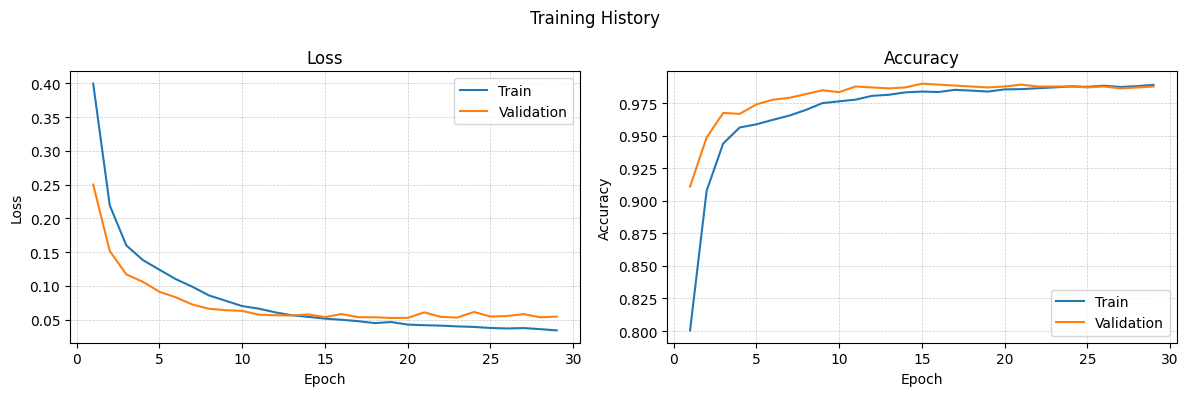

In [7]:
from utils import plot_training_history
plot_training_history(history)

In [11]:
import numpy as np

# Bake CustomFrontend sinc filters into a static Conv1D for TFLite export
custom_layer = training_model.get_layer("sinc_frontend")
baked_filters = custom_layer.get_filters().numpy()

infer_inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
x = tf.keras.layers.Conv1D(
    filters=NUM_FILTERS, kernel_size=KERNEL_SIZE, strides=STRIDE,
    padding="valid", use_bias=False, name="baked_conv"
)(infer_inputs)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Conv1D(
    filters=NUM_FILTERS_2, kernel_size=KERNEL_SIZE_2, strides=STRIDE_2,
    padding="valid", use_bias=False, name="conv_2"
)(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = tf.keras.layers.Dense(DENSE_HIDDEN, activation="relu", name="dense_hidden")(x)
outputs = tf.keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)
inference_model = tf.keras.Model(infer_inputs, outputs, name="sincnet_multilayer_inference")

inference_model.get_layer("baked_conv").set_weights([baked_filters])
for layer in training_model.layers:
    if isinstance(layer, tf.keras.layers.Conv1D):
        inference_model.get_layer("conv_2").set_weights(layer.get_weights())
        break
inference_model.get_layer("dense_hidden").set_weights(training_model.layers[-2].get_weights())
inference_model.get_layer("dense_logits").set_weights(training_model.layers[-1].get_weights())

for batch_audio, _ in test_ds.take(1):
    logits_train = training_model.predict(batch_audio.numpy(), verbose=0)
    logits_infer = inference_model.predict(batch_audio.numpy(), verbose=0)
    print(f"Max abs diff: {np.max(np.abs(logits_train - logits_infer)):.8f}")

Max abs diff: 0.00000000


2026-04-16 21:08:18.572159: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
from utils import build_representative_batches, export_keras_model_to_int8_tflite

rep_batches = build_representative_batches(test_ds, take=100)
try:
    export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"TFLite conversion failed: {e}")

Saved artifact at 'temp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 47872, 1), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135955280199376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135955280199024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135960455999584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135960455999936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135960455999232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135960456000464: TensorSpec(shape=(), dtype=tf.resource, name=None)


2026-04-16 21:08:38.851162: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
W0000 00:00:1776366519.043179  131141 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1776366519.043201  131141 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-16 21:08:39.043518: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: temp_saved_model
2026-04-16 21:08:39.043909: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 21:08:39.043918: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: temp_saved_model
2026-04-16 21:08:39.048088: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-04-16 21:08:39.048553: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-16 21:08:39.066388: I tensorflow/cc/saved_model/

Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_time_multilayer_tf.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


2026-04-16 21:11:55.218895: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model size : 15.3 KB
Est. MFLOPs: 1.997
Arena size : 981.3 KB
=== Binary classifier metrics : TEST SET===
Threshold: 0.7887  (best F2 threshold)
Accuracy : 0.9792
Precision: 0.9554
Recall   : 0.9825
F2 score : 0.9770
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9969


2026-04-16 21:11:59.183725: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


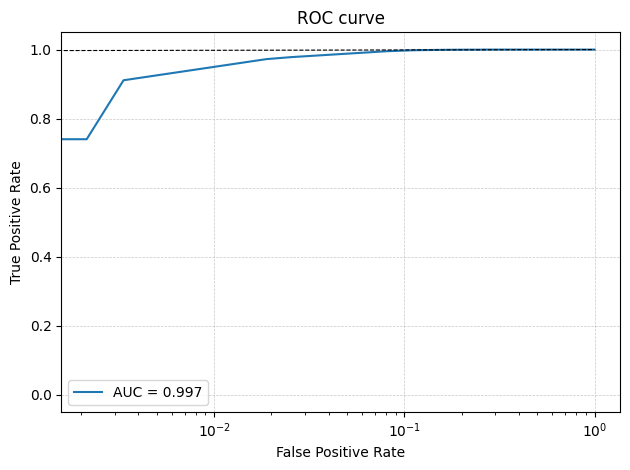

Avg inference: 2.288 ms


In [15]:
from utils import evaluate_tflite_model

train_m, test_m, avg_ms = evaluate_tflite_model(OUT_TFLITE, MODEL_STEM, train_ds, test_ds)
print(f"Avg inference: {avg_ms:.3f} ms")